# 04 — LIME Local Explanations

This notebook uses LIME to explain one local prediction, showing which features push the selected case toward “employed” or “not employed.”


## 1. Install packages

In [1]:
!pip install -q folktables shap lime scikit-learn pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSEmployment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

FIGURE_DIR = Path("../figures")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"
POSTER_WHITE = "white"


## 3. Load the Folktables ACSEmployment dataset

The dataset has been downloaded directly through the `folktables` package and uses California as the default state.

In [4]:
# Load 2024 ACS person-level data for California

import pandas as pd
from folktables import ACSDataSource

data_source = ACSDataSource(
    survey_year="2024",
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=["CA"], download=True)

# 2024 ACS
feature_map = {
    "AGEP": "age",
    "SCHL": "education",
    "MAR": "marital_status",
    "RELSHIPP": "relationship",
    "DIS": "disability",
    "ESP": "employment_status_parent",
    "CIT": "citizenship",
    "MIG": "mobility_status",
    "MIL": "military_service",
    "ANC": "ancestry",
    "NATIVITY": "nativity",
    "DEAR": "hearing_difficulty",
    "DEYE": "vision_difficulty",
    "DREM": "cognitive_difficulty",
    "SEX": "sex",
    "RAC1P": "race"
}

needed_cols = list(feature_map.keys()) + ["ESR"]

df = acs_data[needed_cols].copy()
df = df.rename(columns=feature_map)

# Convert ACS character-coded variables to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Restrict to working-age range for a labor-market analysis
df = df[(df["age"] >= 16) & (df["age"] <= 90)].copy()

# ESR = Employment Status Recode.
# Census codes:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force
#
# For a broader "employed or has job" target:
df["employment"] = df["ESR"].isin([1, 2, 4, 5]).astype(int)

# Original Folktables ACSEmployment target:
# df["employment"] = (df["ESR"] == 1).astype(int)

df = df.drop(columns=["ESR"])

df.head()

,age,education,marital_status,relationship,disability,employment_status_parent,citizenship,mobility_status,military_service,ancestry,nativity,hearing_difficulty,vision_difficulty,cognitive_difficulty,sex,race,employment
0,45,7.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,9,0
1,45,14.0,3,37,1,NaN,1,3.0,4.0,1,1,2,2,1.0,1,3,0
2,21,20.0,5,38,2,NaN,1,1.0,4.0,1,1,2,2,2.0,2,8,1
3,28,18.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,8,0
4,19,18.0,5,38,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,6,0


## 5. Add readable labels for key auditing variables

For the this analysis, the variables of interest are **sex** and **race**.

The ACS sex variable is binary in this task:
- `1 = Male`
- `2 = Female`

Please note that binary encoding does not capture the full range of gender identity and recoding can introduce false hierarchies.

In [5]:
sex_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "American Indian/Alaska Native - specified tribe",
    6: "Asian",
    7: "Native Hawaiian/Pacific Islander",
    8: "Other",
    9: "Two or more races"
}

citizenship_map = {
    1: "Born in U.S.",
    2: "Born in Puerto Rico / U.S. Island Areas",
    3: "Born abroad to U.S. parents",
    4: "U.S. citizen by naturalization",
    5: "Not a U.S. citizen"
}

df["sex_label"] = df["sex"].map(sex_map)
df["race_label"] = df["race"].map(race_map)
df["citizenship_label"] = df["citizenship"].map(citizenship_map)

df[["sex", "sex_label", "race", "race_label", "citizenship", "citizenship_label", "employment"]].head()

,sex,sex_label,race,race_label,citizenship,citizenship_label,employment
0,1,Male,9,Two or more races,1,Born in U.S.,0
1,1,Male,3,American Indian,1,Born in U.S.,0
2,2,Female,8,Other,1,Born in U.S.,1
3,1,Male,8,Other,1,Born in U.S.,0
4,2,Female,6,Asian,1,Born in U.S.,0


## 8. Prepare modeling data

Please note that you need to increase `MAX_ROWS` if you want to recreate this notebook with a larger analysis.

In [6]:
MAX_ROWS = 60000

if len(df) > MAX_ROWS:
    df_model = (
        df.groupby("employment", group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), max(1, int(MAX_ROWS * len(x) / len(df)))),
              random_state=RANDOM_STATE
          ))
          .sample(frac=1, random_state=RANDOM_STATE)
          .copy()
    )
else:
    df_model = df.copy()

print("Modeling dataset shape:", df_model.shape)
display(df_model["employment"].value_counts(normalize=True).to_frame("proportion"))

Modeling dataset shape: (59999, 20)


,proportion
employment,
1,0.571343
0,0.428657


## 9. Define features

This first model includes sex and race so we can audit how the model uses sensitive attributes.

A second model will be trained that removes sex to examine whether gendered prediction gaps remain through proxy variables.

In [7]:
numeric_features = ["age", "education"]

categorical_features_with_sex = [
    "marital_status",
    "relationship",
    "disability",
    "employment_status_parent",
    "citizenship_label",
    "mobility_status",
    "military_service",
    "ancestry",
    "nativity",
    "hearing_difficulty",
    "vision_difficulty",
    "cognitive_difficulty",
    "sex_label",
    "race_label"
]

features_with_sex = numeric_features + categorical_features_with_sex

target_col = "employment"

model_data = df_model[features_with_sex + [target_col]].copy()

# Treat coded ACS fields as categories
for col in categorical_features_with_sex:
    model_data[col] = model_data[col].astype(str)

X = model_data[features_with_sex]
y = model_data[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (47999, 16)
Test shape: (12000, 16)


## 10. Helper functions


In [8]:
def make_onehot_encoder():
    """
    Handles scikit-learn version differences.
    Newer versions use sparse_output; older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    classifier = RandomForestClassifier(
        n_estimators=150,
        max_depth=9,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    return model


def clean_feature_name(name):
    """Make transformed feature names easier to read in plots."""
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    name = name.replace("_", " ")
    return name


def transform_to_dataframe(model, X_input):
    """Apply the model preprocessor and return a dense DataFrame with readable feature names."""
    preprocessor = model.named_steps["preprocessor"]
    transformed = preprocessor.transform(X_input)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    feature_names = [clean_feature_name(n) for n in preprocessor.get_feature_names_out()]
    return pd.DataFrame(transformed, columns=feature_names, index=X_input.index)


def summarize_group_predictions(model, X_input, y_true, group_series, group_name="group"):
    """Summarize actual and predicted outcomes by a demographic group."""
    proba = model.predict_proba(X_input)[:, 1]
    pred = (proba >= 0.50).astype(int)

    results = pd.DataFrame({
        group_name: group_series.values,
        "actual": np.array(y_true),
        "predicted": pred,
        "predicted_probability": proba
    }, index=X_input.index)

    summary = (
        results.groupby(group_name)
        .agg(
            n=("actual", "size"),
            actual_employment_rate=("actual", "mean"),
            predicted_employment_rate=("predicted", "mean"),
            mean_predicted_probability=("predicted_probability", "mean")
        )
        .sort_values("predicted_employment_rate", ascending=False)
    )

    return summary, results


def get_positive_class_shap_values(explainer, X_transformed_df):
    """Return SHAP values for the positive class across SHAP versions."""
    raw_values = explainer.shap_values(X_transformed_df, check_additivity=False)

    if isinstance(raw_values, list):
        shap_values = raw_values[1]
    elif hasattr(raw_values, "ndim") and raw_values.ndim == 3:
        shap_values = raw_values[:, :, 1]
    else:
        shap_values = raw_values

    return shap_values


def get_positive_class_base_value(explainer):
    """Return expected/base value for the positive class."""
    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)) and np.array(base_value).ndim > 0:
        return base_value[1]
    return base_value


def disparate_impact_ratio(summary_table, protected_group="Female", reference_group="Male", rate_col="predicted_employment_rate"):
    """
    Compute a simple disparate impact ratio:
    protected group selection rate / reference group selection rate.
    """
    if protected_group not in summary_table.index or reference_group not in summary_table.index:
        return np.nan

    ref_rate = summary_table.loc[reference_group, rate_col]
    protected_rate = summary_table.loc[protected_group, rate_col]

    if ref_rate == 0:
        return np.nan

    return protected_rate / ref_rate

## 11. Train Model A: includes sex and race

Please note that this model is not meant to be a deployable hiring system. It is used purely for auditing purposes!

The purpose is to gain insight into:

> What the model learns when sensitive attributes and historically patterned variables are included

In [9]:
model_with_sex = build_pipeline(numeric_features, categorical_features_with_sex)
model_with_sex.fit(X_train, y_train)

y_pred = model_with_sex.predict(X_test)
y_proba = model_with_sex.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not employed", "Employed"]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7763

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.69      0.73      5144
    Employed       0.78      0.84      0.81      6856

    accuracy                           0.78     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.78      0.78      0.77     12000


Confusion matrix:
[[3549 1595]
 [1089 5767]]


In [10]:
X_test_transformed = transform_to_dataframe(model_with_sex, X_test)
SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed))
X_shap = X_test_transformed.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
rf_classifier = model_with_sex.named_steps["classifier"]

print("Transformed test sample shape:", X_shap.shape)


Transformed test sample shape: (1000, 73)


## 16. LIME local explanation

LIME explains one prediction by approximating the model locally around that case.

LIME explanation as list:
relationship 37 <= 0.00: 0.1609
disability 1 <= 0.00: 0.1164
military service nan <= 0.00: 0.1132
employment status parent 7.0 <= 0.00: 0.0984
age <= -0.85: 0.0905
marital status 2 <= 0.00: 0.0845
race label Alaska Native <= 0.00: -0.0789
relationship 26 <= 0.00: 0.0730
employment status parent 3.0 <= 0.00: 0.0662
citizenship label Born in Puerto Rico / U.S. Island Areas <= 0.00: 0.0642


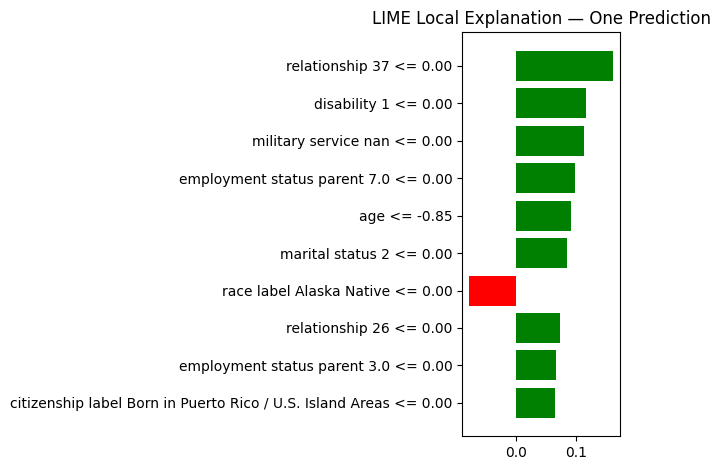

In [11]:
LIME_TRAIN_SIZE = min(5000, len(X_test_transformed))
lime_background = X_test_transformed.sample(LIME_TRAIN_SIZE, random_state=RANDOM_STATE)

lime_explainer = LimeTabularExplainer(
    training_data=lime_background.values,
    feature_names=lime_background.columns.tolist(),
    class_names=["Not employed", "Employed"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

def lime_predict_proba(transformed_array):
    return rf_classifier.predict_proba(transformed_array)

lime_case_index = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.iloc[lime_case_index].values,
    predict_fn=lime_predict_proba,
    num_features=10
)

print("LIME explanation as list:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

fig = lime_exp.as_pyplot_figure()
plt.title("LIME Local Explanation — One Prediction")
plt.tight_layout()
plt.show()


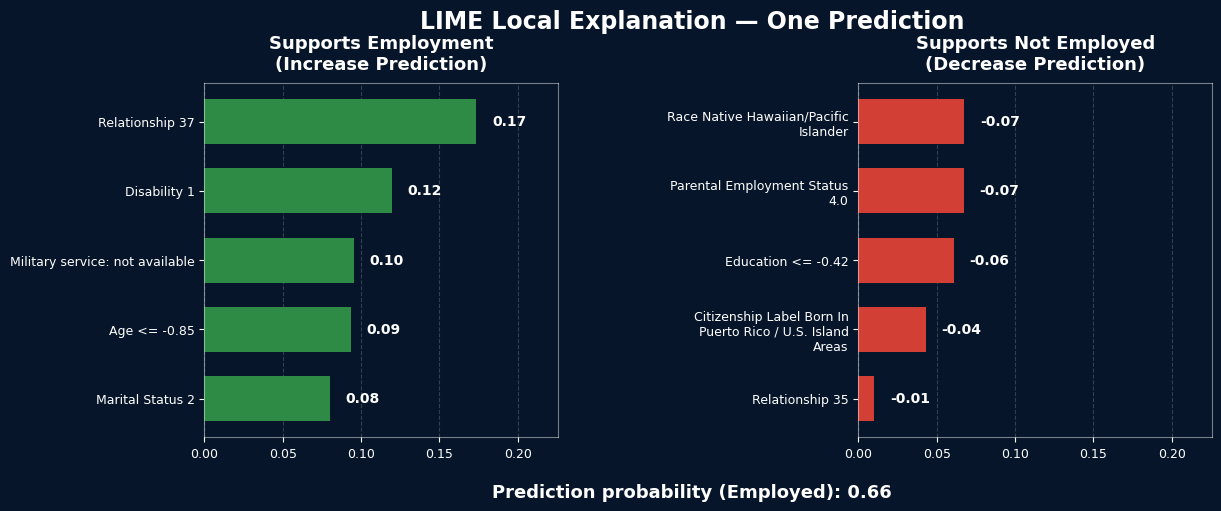

In [14]:
POSTER_BG = "#061529"
POSTER_WHITE = "white"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"

lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.iloc[lime_case_index].values,
    predict_fn=lime_predict_proba,
    num_features=14
)

lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["feature", "weight"]
)

# Clean labels
def clean_lime_label(label):
    label = str(label)

    replacements = {
        "Relationship 37 <= 0.00": "Relationship category 37",
        "Disability 1 <= 0.00": "Disability-related factor",
        "military service nan <= 0.00": "Military service: not available",
        "Parental employment status 7.0 <= 0.00": "Parental employment status",
        "Age <= -0.85": "Younger age group",
        "Race Alaska Native <= 0.00": "Race category: Alaska Native",
    }

    if label in replacements:
        return replacements[label]

    label = label.replace("num__", "")
    label = label.replace("cat__", "")
    label = label.replace("_", " ")

    label = label.replace("age", "Age")
    label = label.replace("education", "Education")
    label = label.replace("disability", "Disability")
    label = label.replace("relationship", "Relationship")
    label = label.replace("marital status", "Marital status")
    label = label.replace("military service", "Military service")
    label = label.replace("employment status parent", "Parental employment status")
    label = label.replace("race label", "Race")

    # Remove hard-to-read threshold notation
    label = label.replace(" <= 0.00", "")
    label = label.replace(" > 0.00", "")

    # Wrap longer labels so they do not crowd the plot
    label = label.strip().title()
    label = "\n".join(textwrap.wrap(label, width=28))

    return label

lime_df["label"] = lime_df["feature"].apply(clean_lime_label)

# Split into positive and negative
positive = (
    lime_df[lime_df["weight"] > 0]
    .sort_values("weight", ascending=False)
    .head(5)
    .sort_values("weight", ascending=True)
)

negative = lime_df[lime_df["weight"] < 0].copy()
negative["abs_weight"] = negative["weight"].abs()

negative = (
    negative
    .sort_values("abs_weight", ascending=False)
    .head(5)
    .sort_values("abs_weight", ascending=True)
)

# Get prediction probability dynamically
try:
    pred_prob_employed = lime_predict_proba(
        X_shap.iloc[[lime_case_index]].values
    )[0, 1]
except:
    pred_prob_employed = 0.73

# Plot with dark notebook preview background
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4.6),
    facecolor=POSTER_BG,
    gridspec_kw={"wspace": 0.85}
)

# Left panel: positive
axes[0].barh(
    positive["label"],
    positive["weight"],
    color=POSTER_GREEN,
    height=0.65
)

axes[0].set_title(
    "Supports Employment\n(Increase Prediction)",
    color=POSTER_WHITE,
    fontsize=13,
    fontweight="bold",
    pad=10
)

for i, value in enumerate(positive["weight"]):
    axes[0].text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        color=POSTER_WHITE,
        fontsize=10,
        fontweight="bold"
    )

# Right panel: negative, plotted as absolute value for readability purposes
axes[1].barh(
    negative["label"],
    negative["abs_weight"],
    color=POSTER_RED,
    height=0.65
)

axes[1].set_title(
    "Supports Not Employed\n(Decrease Prediction)",
    color=POSTER_WHITE,
    fontsize=13,
    fontweight="bold",
    pad=10
)

for i, row in enumerate(negative.itertuples()):
    axes[1].text(
        row.abs_weight + 0.01,
        i,
        f"{row.weight:.2f}",
        va="center",
        color=POSTER_WHITE,
        fontsize=10,
        fontweight="bold"
    )

# Formatting
max_value = max(
    positive["weight"].max() if len(positive) else 0,
    negative["abs_weight"].max() if len(negative) else 0
)

for ax in axes:
    ax.set_xlim(0, max_value * 1.30)

    ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=9)
    ax.tick_params(axis="x", colors=POSTER_WHITE, labelsize=9)

    ax.grid(axis="x", color=POSTER_WHITE, alpha=0.18, linestyle="--")
    ax.set_axisbelow(True)

    # Dark preview background
    ax.set_facecolor(POSTER_BG)

    for spine in ax.spines.values():
        spine.set_color(POSTER_WHITE)
        spine.set_alpha(0.45)

# title
fig.suptitle(
    "LIME Local Explanation — One Prediction",
    color=POSTER_WHITE,
    fontsize=17,
    fontweight="bold",
    y=1.04
)

fig.text(
    0.5,
    -0.02,
    f"Prediction probability (Employed): {pred_prob_employed:.2f}",
    ha="center",
    color=POSTER_WHITE,
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

# Save transparent PNG
plt.savefig(
    FIGURE_DIR / "lime_local_explanation_poster_clean.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## Interpretation note

Please note that LIME is useful for local storytelling and auditing one prediction. It does not prove discrimination and does not solve fairness by itself.
